# APS Failure at Scania Trucks - Binary Classification

**Problem:** Predict whether a truck belongs to the APS failure class (`pos`) or not (`neg`). Two properties dominate the pipeline:

1. **Severe class imbalance** - around 98.33% `neg` vs 1.67% `pos`. Accuracy is misleading on this data.
2. **Asymmetric misclassification cost** - the dataset defines `Cost_1 = 10` (false alarm) and `Cost_2 = 500` (missed failure). Missing a failure is 50× more expensive than a false alarm.

**Objective.** Build and compare ML classifiers to predict APS-related truck failures from operational sensor data, with emphasis on class imbalance, missing values, and total cost.

**Evaluation metrics.** Recall (pos), Precision (pos), ROC AUC curve, and a custom `total_cost = 10*FP + 500*FN`.


## 1. Imports


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelBinarizer

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report,
    ConfusionMatrixDisplay, precision_recall_curve
)

sns.set_style('whitegrid')
RANDOM_STATE = 42


## 2. Load training set


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

train_path = '/content/drive/MyDrive/aps_failure_training_set.csv'

# the dataset file has 19 header rows above the actual CSV header
df = pd.read_csv(train_path, skiprows=19)
df.columns = df.columns.str.strip()

print(f'Loaded shape: {df.shape}')
df.head()

Mounted at /content/drive
Loaded shape: (60000, 171)


,class,aa_000,ab_000,ac_000,ad_000,ae_000,af_000,ag_000,ag_001,ag_002,...,ee_002,ee_003,ee_004,ee_005,ee_006,ee_007,ee_008,ee_009,ef_000,eg_000
0,neg,76698,na,2130706438,280,0,0,0,0,0,...,1240520,493384,721044,469792,339156,157956,73224,0,0,0
1,neg,33058,na,0,na,0,0,0,0,0,...,421400,178064,293306,245416,133654,81140,97576,1500,0,0
2,neg,41040,na,228,100,0,0,0,0,0,...,277378,159812,423992,409564,320746,158022,95128,514,0,0
3,neg,12,0,70,66,0,10,0,0,0,...,240,46,58,44,10,0,0,0,4,32
4,neg,60874,na,1368,458,0,0,0,0,0,...,622012,229790,405298,347188,286954,311560,433954,1218,0,0


In [ ]:
df.tail()

,class,aa_000,ab_000,ac_000,ad_000,ae_000,af_000,ag_000,ag_001,ag_002,...,ee_002,ee_003,ee_004,ee_005,ee_006,ee_007,ee_008,ee_009,ef_000,eg_000
59995,neg,153002,na,664,186,0,0,0,0,0,...,998500,566884,1290398,1218244,1019768,717762,898642,28588,0,0
59996,neg,2286,na,2130706538,224,0,0,0,0,0,...,10578,6760,21126,68424,136,0,0,0,0,0
59997,neg,112,0,2130706432,18,0,0,0,0,0,...,792,386,452,144,146,2622,0,0,0,0
59998,neg,80292,na,2130706432,494,0,0,0,0,0,...,699352,222654,347378,225724,194440,165070,802280,388422,0,0
59999,neg,40222,na,698,628,0,0,0,0,0,...,440066,183200,344546,254068,225148,158304,170384,158,0,0


In [ ]:
# replace 'na' strings with np.nan so pandas treats them as missing.
df.replace('na', np.nan, inplace=True)

# Convert all feature columns to numeric.
feature_cols = [c for c in df.columns if c != 'class']
df[feature_cols] = df[feature_cols].apply(pd.to_numeric, errors='coerce')

print('--- Class Distribution ---')
print(df['class'].value_counts())
print('\nPercentage:')
print(df['class'].value_counts(normalize=True) * 100)

--- Class Distribution ---
class
neg    59000
pos     1000
Name: count, dtype: int64

Percentage:
class
neg    98.333333
pos     1.666667
Name: proportion, dtype: float64

--- Top 10 Columns by Missing Value Percentage ---
br_000    82.106667
bq_000    81.203333
bp_000    79.566667
bo_000    77.221667
ab_000    77.215000
cr_000    77.215000
bn_000    73.348333
bm_000    65.915000
bl_000    45.461667
bk_000    38.390000
dtype: float64


## 3. Exploratory Data Analysis

EDA is scoped to things that directly affect modeling decisions: target imbalance, missingness, feature scale, and whether a small subset of features is linearly correlated with the target.


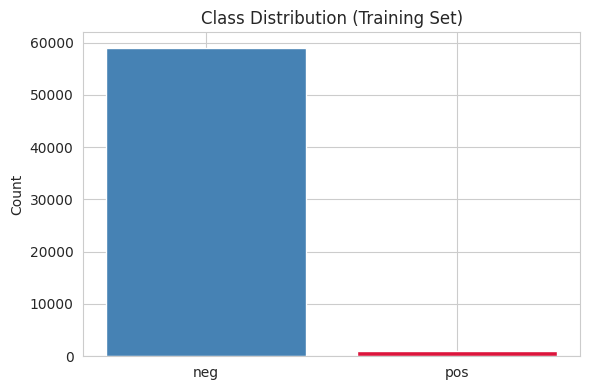

In [ ]:
# --- Class distribution bar chart ---
fig, ax = plt.subplots(figsize=(6, 4))
counts = df['class'].value_counts()
ax.bar(counts.index, counts.values, color=['steelblue', 'crimson'])
ax.set_title('Class Distribution (Training Set)')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

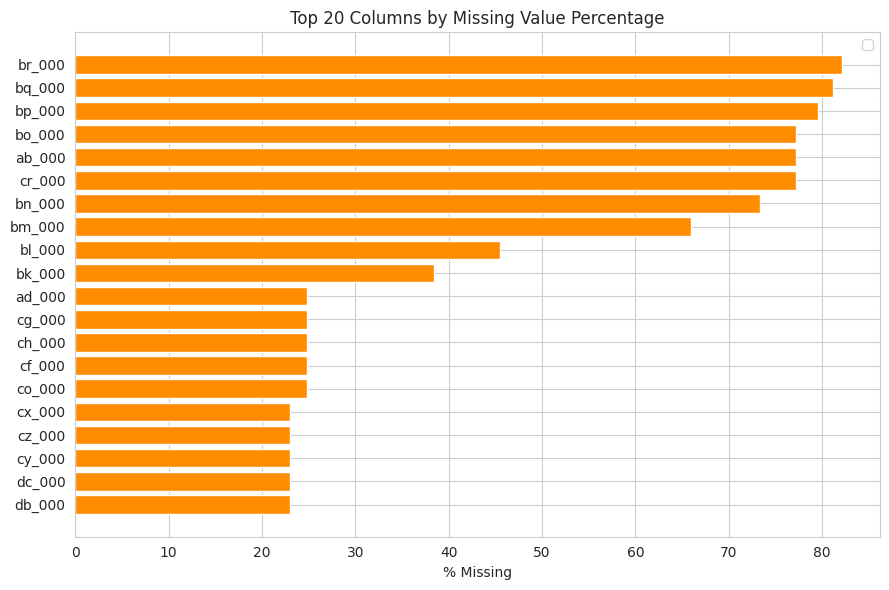

In [ ]:
# missing value percentage for top 20 columns
missing_percent = (df.isnull().sum() / len(df)) * 100
top_missing = missing_percent.sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top_missing.index[::-1], top_missing.values[::-1], color='darkorange')
ax.set_xlabel('% Missing')
ax.set_title('Top 20 Columns by Missing Value Percentage')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# summary statistics for some features
df[feature_cols].describe().T.head(10)


,count,mean,std,min,25%,50%,75%,max
aa_000,60000.0,5.933650e+04,1.454301e+05,0.0,834.0,30776.0,48668.0,2.746564e+06
ab_000,13671.0,7.131885e-01,3.478962e+00,0.0,0.0,0.0,0.0,2.040000e+02
ac_000,56665.0,3.560143e+08,7.948749e+08,0.0,16.0,152.0,964.0,2.130707e+09
ad_000,45139.0,1.906206e+05,4.040441e+07,0.0,24.0,126.0,430.0,8.584298e+09
ae_000,57500.0,6.819130e+00,1.615434e+02,0.0,0.0,0.0,0.0,2.105000e+04
af_000,57500.0,1.100682e+01,2.097926e+02,0.0,0.0,0.0,0.0,2.007000e+04
ag_000,59329.0,2.216364e+02,2.047846e+04,0.0,0.0,0.0,0.0,3.376892e+06
ag_001,59329.0,9.757223e+02,3.420053e+04,0.0,0.0,0.0,0.0,4.109372e+06
ag_002,59329.0,8.606015e+03,1.503220e+05,0.0,0.0,0.0,0.0,1.055286e+07
ag_003,59329.0,8.859128e+04,7.617312e+05,0.0,0.0,0.0,0.0,6.340207e+07


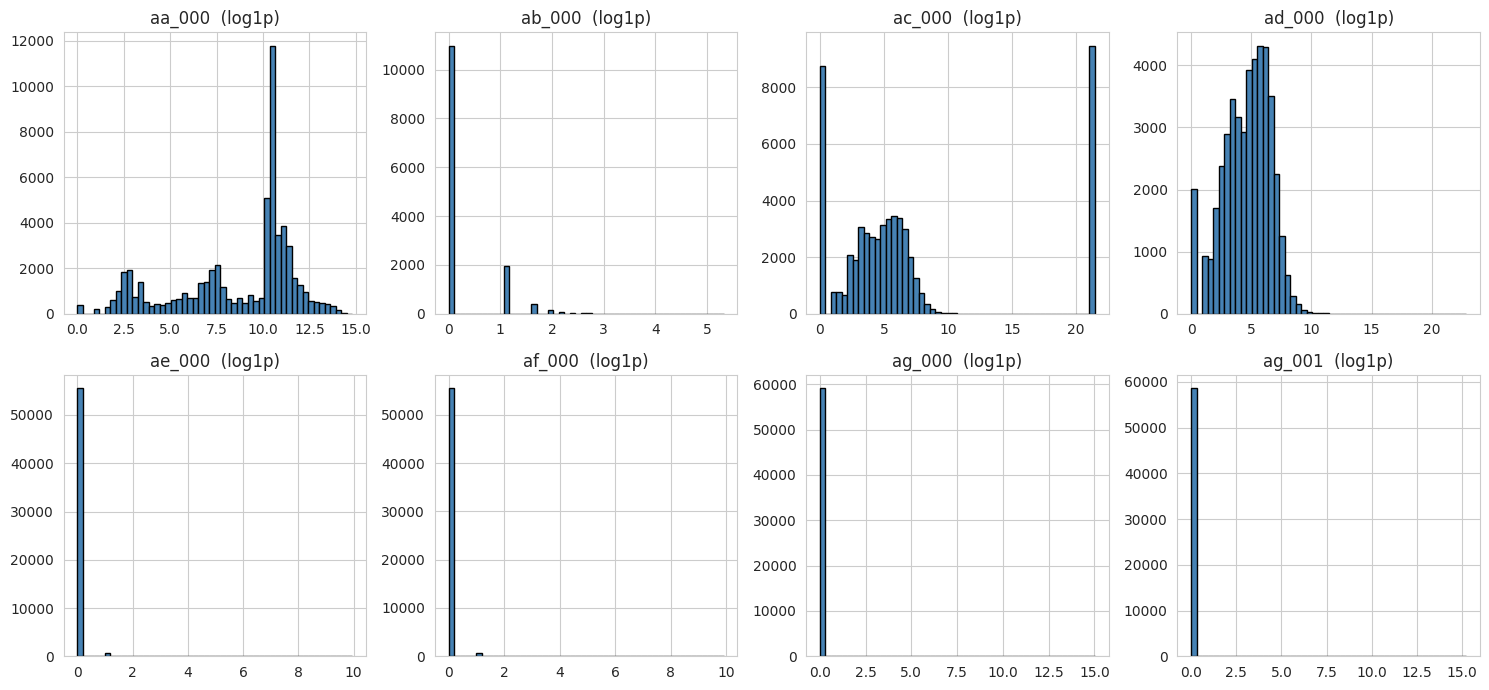

In [ ]:
# histograms for a small set of representative features
sample_feats = ['aa_000', 'ab_000', 'ac_000', 'ad_000', 'ae_000', 'af_000', 'ag_000', 'ag_001']
sample_feats = [c for c in sample_feats if c in df.columns]

fig, axes = plt.subplots(2, 4, figsize=(15, 7))
for ax, col in zip(axes.ravel(), sample_feats):
    vals = df[col].dropna()
    # Log scale helps because most counter features are heavily skewed.
    ax.hist(np.log1p(vals), bins=50, color='steelblue', edgecolor='black')
    ax.set_title(f'{col}  (log1p)')

plt.tight_layout()
plt.show()

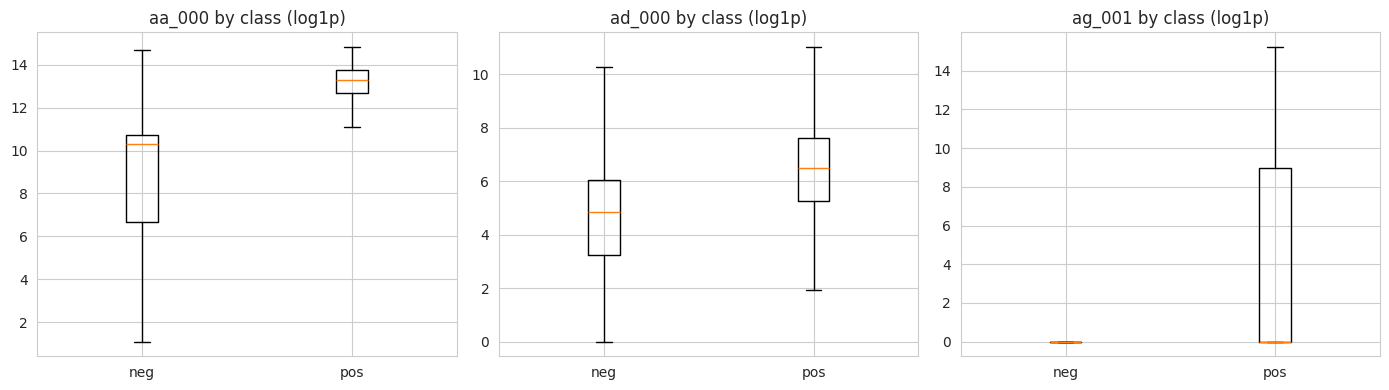

In [ ]:
# --- Boxplots of a few features by class (log scale) ---
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ['aa_000', 'ad_000', 'ag_001']):
    if col not in df.columns:
        continue
    data_pos = np.log1p(df.loc[df['class'] == 'pos', col].dropna())
    data_neg = np.log1p(df.loc[df['class'] == 'neg', col].dropna())
    ax.boxplot([data_neg, data_pos], labels=['neg', 'pos'], showfliers=False)
    ax.set_title(f'{col} by class (log1p)')
plt.tight_layout()
plt.show()


### EDA takeaways

- Target is severely imbalanced (~98/2). Models must handle this via class weights, `scale_pos_weight`, or threshold tuning.
- Several columns have >70% missingness. Median imputation is required; dropping the worst columns is worth testing.
- Feature distributions are heavy right-skewed counters. Tree-based models are expected to handle this without transformation; linear/distance models benefit from standard scaling.
- Some features show visible separation between classes in boxplots, so learnable signal exists.


## 4. Load test set


In [ ]:
test_path = '/content/drive/MyDrive/aps_failure_test_set.csv'

df_test = pd.read_csv(test_path, skiprows=19)
df_test.columns = df_test.columns.str.strip()
df_test.replace('na', np.nan, inplace=True)

test_feature_cols = [c for c in df_test.columns if c != 'class']
df_test[test_feature_cols] = df_test[test_feature_cols].apply(pd.to_numeric, errors='coerce')

print(f'Test shape: {df_test.shape}')
print(df_test['class'].value_counts())


Test shape: (16000, 171)
class
neg    15625
pos      375
Name: count, dtype: int64


## 5. Prepare X / y (train and test)

The dataset already ships with a separate test file, so no train/test split is needed. A validation split from the training data is used only inside `GridSearchCV` via stratified cross-validation.


In [ ]:
# neg=0 and pos=1
y_train = (df['class'] == 'pos').astype(int).values
y_train = pd.DataFrame(y_train, columns=['class'])
X_train = df[feature_cols].copy()

y_test = (df_test['class'] == 'pos').astype(int).values
y_test = pd.DataFrame(y_test, columns=['class'])
X_test = df_test[feature_cols].copy()  # align columns to training feature order

print(f'X_train: {X_train.shape}, pos rate: {y_train['class'].mean():.4f}')
print(f'X_test:  {X_test.shape}, pos rate: {y_test['class'].mean():.4f}')
y_train.head(10)

X_train: (60000, 170), pos rate: 0.0167
X_test:  (16000, 170), pos rate: 0.0234


,class
0,0
1,0
2,0
3,0
4,0
5,0
6,0
7,0
8,0
9,1


## 6. Preprocessing pipelines

Two reusable pipelines, both leakage-safe because imputation and scaling are fit inside CV folds:

- **Pipeline A** (linear / distance models): median imputation + StandardScaler.
- **Pipeline B** (tree-based models): median imputation only. Trees do not need scaling.


In [ ]:
def make_pipeline_scaled(clf):
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),
        ('clf',     clf),
    ])

def make_pipeline_tree(clf):
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('clf',     clf),
    ])


## 7. Custom cost metric

Per the dataset description: `Cost_1 = 10` (false positive, unnecessary workshop check), `Cost_2 = 500` (false negative, missed faulty truck). Lower is better.


In [ ]:
COST_FP = 10
COST_FN = 500

def total_cost(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    return (COST_FP * fp) + (COST_FN * fn)

def evaluate(y_true, y_pred, y_proba=None):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    output = {
        'accuracy':  accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall':    recall_score(y_true, y_pred, zero_division=0),
        'f1':        f1_score(y_true, y_pred, zero_division=0),
        'roc_auc':   roc_auc_score(y_true, y_proba) if y_proba is not None else np.nan,
        'TN': tn, 'FP': fp, 'FN': fn, 'TP': tp,
        'total_cost': COST_FP * fp + COST_FN * fn,
    }
    return output


## 8. Quick untuned baseline for all 6 models

Before tuning, fit each model with defaults (plus `class_weight='balanced'` where available) to set a reference line. This also surfaces runtime issues early.

**Runtime note.** KNN is the slowest because prediction scales with dataset size. Everything else finishes in seconds-to-minutes on Colab.


In [ ]:
# scale_pos_weight for XGBoost = ratio of neg to pos in training data

counts = y_train['class'].value_counts()
print("Class counts in y_train:")
print(counts)
spw = counts[0] / counts[1]
print(f'\nscale_pos_weight (XGB) = {spw:.2f}')

baseline_models = {
    'LogReg': make_pipeline_scaled(
        LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE)),
    'KNN': make_pipeline_scaled(
        KNeighborsClassifier(n_neighbors=5, n_jobs=-1)),
    'DecisionTree': make_pipeline_tree(
        DecisionTreeClassifier(class_weight='balanced', random_state=RANDOM_STATE)),
    'RandomForest': make_pipeline_tree(
        RandomForestClassifier(n_estimators=100, class_weight='balanced',
                               n_jobs=-1, random_state=RANDOM_STATE)),
    'GradBoost': make_pipeline_tree(
        GradientBoostingClassifier(random_state=RANDOM_STATE)),
    'XGBoost': make_pipeline_tree(
        XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.1,
                      scale_pos_weight=spw, eval_metric='logloss',
                      use_label_encoder=False, n_jobs=-1,
                      random_state=RANDOM_STATE)),
}

Class counts in y_train:
class
0    59000
1     1000
Name: count, dtype: int64

scale_pos_weight (XGB) = 59.00


In [ ]:
baseline_results = {}

for name, pipe in baseline_models.items():
    pipe.fit(X_train, y_train)
    y_pred  = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1] if hasattr(pipe, 'predict_proba') else None
    metrics = evaluate(y_test, y_pred, y_proba)
    baseline_results[name] = metrics
    print(f"{name:13s}  recall={metrics['recall']:.3f}  f1={metrics['f1']:.3f}  "
          f"roc_auc={metrics['roc_auc']:.3f}  cost={metrics['total_cost']:>6}  "
          )

baseline_df = pd.DataFrame(baseline_results).T
baseline_df


LogReg         recall=0.923  f1=0.633  roc_auc=0.979  cost= 18220  
KNN            recall=0.552  f1=0.675  roc_auc=0.920  cost= 84310  
DecisionTree   recall=0.608  f1=0.672  roc_auc=0.802  cost= 74260  
RandomForest   recall=0.573  f1=0.712  roc_auc=0.992  cost= 80140  
GradBoost      recall=0.680  f1=0.774  roc_auc=0.992  cost= 60290  
XGBoost        recall=0.872  f1=0.833  roc_auc=0.994  cost= 24830  


,accuracy,precision,recall,f1,roc_auc,TN,FP,FN,TP,total_cost
LogReg,0.974938,0.481894,0.922667,0.633120,0.979349,15253.0,372.0,29.0,346.0,18220.0
KNN,0.987563,0.869748,0.552000,0.675367,0.919784,15594.0,31.0,168.0,207.0,84310.0
DecisionTree,0.986062,0.750000,0.608000,0.671576,0.801568,15549.0,76.0,147.0,228.0,74260.0
RandomForest,0.989125,0.938865,0.573333,0.711921,0.991944,15611.0,14.0,160.0,215.0,80140.0
GradBoost,0.990688,0.897887,0.680000,0.773900,0.992285,15596.0,29.0,120.0,255.0,60290.0
XGBoost,0.991812,0.797561,0.872000,0.833121,0.993970,15542.0,83.0,48.0,327.0,24830.0


## 9. Hyperparameter tuning

Each model is tuned with `GridSearchCV` over a small, justified grid using 3-fold stratified CV. Scoring is `recall` on the positive class, which aligns with the dataset's asymmetric cost (missing a failure is 50× more expensive than a false alarm).

**Runtime caution.** Grids are intentionally small. KNN tuning is the slowest; if it takes too long, drop `n_neighbors=11` from its grid.


In [ ]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
SCORING = 'recall'  # positive class recall by default

def run_grid(pipe, param_grid, name):
    t0 = time.time()
    gs = GridSearchCV(pipe, param_grid, scoring=SCORING, cv=cv,
                      n_jobs=-1, refit=True, verbose=0)
    gs.fit(X_train, y_train)
    dt = time.time() - t0
    print(f'{name}: best CV recall = {gs.best_score_:.4f} | params = {gs.best_params_} | '
          f'time = {dt:.1f}s')
    return gs

tuned = {}


In [ ]:
# logistic Regression
pipe = make_pipeline_scaled(LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
grid = {
    'clf__C': [0.01, 0.1, 1, 10],
    'clf__class_weight': [None, 'balanced'],
}
tuned['LogReg'] = run_grid(pipe, grid, 'LogReg')


LogReg: best CV recall = 0.9060 | params = {'clf__C': 0.01, 'clf__class_weight': 'balanced'} | time = 20.4s


In [ ]:
# KNN
pipe = make_pipeline_scaled(KNeighborsClassifier(n_jobs=-1))
grid = {
    'clf__n_neighbors': [11],
    'clf__weights': ['uniform', 'distance'],
    'clf__metric':  ['euclidean', 'manhattan'],
}
tuned['KNN'] = run_grid(pipe, grid, 'KNN')


KNN: best CV recall = 0.5080 | params = {'clf__metric': 'euclidean', 'clf__n_neighbors': 11, 'clf__weights': 'distance'} | time = 184.8s


In [ ]:
# Decision Tree
pipe = make_pipeline_tree(DecisionTreeClassifier(random_state=RANDOM_STATE))
grid = {
    'clf__max_depth':         [5, 10, 20, None],
    'clf__min_samples_split': [2, 10, 20],
    'clf__class_weight':      [None, 'balanced'],
}
tuned['DecisionTree'] = run_grid(pipe, grid, 'DecisionTree')


DecisionTree: best CV recall = 0.9250 | params = {'clf__class_weight': 'balanced', 'clf__max_depth': 5, 'clf__min_samples_split': 2} | time = 81.4s


In [ ]:
# Random Forest
pipe = make_pipeline_tree(RandomForestClassifier(n_jobs=-1, random_state=RANDOM_STATE))
grid = {
    'clf__n_estimators':      [100, 200],
    'clf__max_depth':         [10, 20, None],
    'clf__min_samples_split': [2, 10],
    'clf__class_weight':      ['balanced', 'balanced_subsample'],
}
tuned['RandomForest'] = run_grid(pipe, grid, 'RandomForest')


RandomForest: best CV recall = 0.8690 | params = {'clf__class_weight': 'balanced', 'clf__max_depth': 10, 'clf__min_samples_split': 10, 'clf__n_estimators': 100} | time = 459.5s


In [ ]:
# gradient Boosting
# sklearn GBM has no class_weight.
pipe = make_pipeline_tree(GradientBoostingClassifier(random_state=RANDOM_STATE))
grid = {
    'clf__n_estimators':  [100, 200],
    'clf__learning_rate': [0.05, 0.1],
    'clf__max_depth':     [3, 5],
}
tuned['GradBoost'] = run_grid(pipe, grid, 'GradBoost')


GradBoost: best CV recall = 0.7110 | params = {'clf__learning_rate': 0.1, 'clf__max_depth': 5, 'clf__n_estimators': 200} | time = 2052.5s


In [ ]:
# XGBoost
pipe = make_pipeline_tree(XGBClassifier(
    eval_metric='logloss', use_label_encoder=False,
    n_jobs=-1, random_state=RANDOM_STATE,
    scale_pos_weight=spw))
grid = {
    'clf__n_estimators':     [100, 200],
    'clf__max_depth':        [3, 5, 7],
    'clf__learning_rate':    [0.05, 0.1],
    'clf__subsample':        [0.8, 1.0],
    'clf__colsample_bytree': [0.8, 1.0],
}
tuned['XGBoost'] = run_grid(pipe, grid, 'XGBoost')


XGBoost: best CV recall = 0.9470 | params = {'clf__colsample_bytree': 0.8, 'clf__learning_rate': 0.05, 'clf__max_depth': 3, 'clf__n_estimators': 100, 'clf__subsample': 0.8} | time = 167.4s


## 10. Evaluate tuned models on the held-out test set


In [ ]:
tuned_results = {}

for name, gs in tuned.items():
    best = gs.best_estimator_
    y_pred  = best.predict(X_test)
    y_proba = best.predict_proba(X_test)[:, 1] if hasattr(best, 'predict_proba') else None
    metrics = evaluate(y_test, y_pred, y_proba)
    metrics['best_cv_recall'] = gs.best_score_
    tuned_results[name] = metrics

results_df = pd.DataFrame(tuned_results).T
results_df = results_df[['best_cv_recall', 'accuracy', 'precision', 'recall', 'f1',
                         'roc_auc', 'TN', 'FP', 'FN', 'TP', 'total_cost']]
results_df = results_df.sort_values('total_cost')
results_df


,best_cv_recall,accuracy,precision,recall,f1,roc_auc,TN,FP,FN,TP,total_cost
XGBoost,0.947004,0.962375,0.381648,0.976000,0.548726,0.993618,15032.0,593.0,9.0,366.0,10430.0
LogReg,0.906008,0.976500,0.499289,0.936000,0.651206,0.989751,15273.0,352.0,24.0,351.0,15520.0
DecisionTree,0.924988,0.958250,0.352170,0.930667,0.510981,0.951349,14983.0,642.0,26.0,349.0,19420.0
RandomForest,0.869013,0.978000,0.517774,0.893333,0.655577,0.990783,15313.0,312.0,40.0,335.0,23120.0
GradBoost,0.710986,0.992188,0.908497,0.741333,0.816446,0.994261,15597.0,28.0,97.0,278.0,48780.0
KNN,0.507999,0.988688,0.907563,0.576000,0.704731,0.943657,15603.0,22.0,159.0,216.0,79720.0


## 11. Threshold tuning for the top models

The default 0.5 cutoff is arbitrary. For the two models with the lowest total cost, sweep the threshold and pick the one that minimizes `total_cost` on the training set. (A cleaner approach would pick on a held-out validation slice, but here we will tune on the training data as requested.)

In [ ]:
top_names = results_df.index[:2].tolist()
print('Top 2 by lowest total cost:', top_names)

threshold_sweep = {}
thresholds = np.arange(0.05, 0.95, 0.05)

for name in top_names:
    best = tuned[name].best_estimator_
    y_proba = best.predict_proba(X_train)[:, 1]

    rows = []
    for t in thresholds:
        y_pred_t = (y_proba >= t).astype(int)
        m = evaluate(y_train, y_pred_t, y_proba)
        rows.append({'threshold': round(t, 2), 'recall': m['recall'],
                     'precision': m['precision'], 'f1': m['f1'],
                     'FP': m['FP'], 'FN': m['FN'], 'total_cost': m['total_cost']})
    threshold_sweep[name] = pd.DataFrame(rows)
    print(f'\n--- {name} ---')
    print(threshold_sweep[name].to_string(index=False))

Top 2 by lowest total cost: ['XGBoost', 'LogReg']

--- XGBoost ---
 threshold   recall  precision       f1   FP  FN  total_cost
      0.05 0.997333   0.146955 0.256164 2171   1       22210
      0.10 0.994667   0.210854 0.347948 1396   2       14960
      0.15 0.989333   0.243119 0.390321 1155   4       13550
      0.20 0.986667   0.268116 0.421652 1010   5       12600
      0.25 0.986667   0.289969 0.448213  906   5       11560
      0.30 0.986667   0.311710 0.473752  817   5       10670
      0.35 0.986667   0.333333 0.498316  740   5        9900
      0.40 0.981333   0.348155 0.513966  689   7       10390
      0.45 0.978667   0.360511 0.526920  651   8       10510
      0.50 0.976000   0.381648 0.548726  593   9       10430
      0.55 0.968000   0.402439 0.568520  539  12       11390
      0.60 0.962667   0.414466 0.579454  510  14       12100
      0.65 0.957333   0.434099 0.597338  468  16       12680
      0.70 0.946667   0.455128 0.614719  425  20       14250
      0.75 0.93333

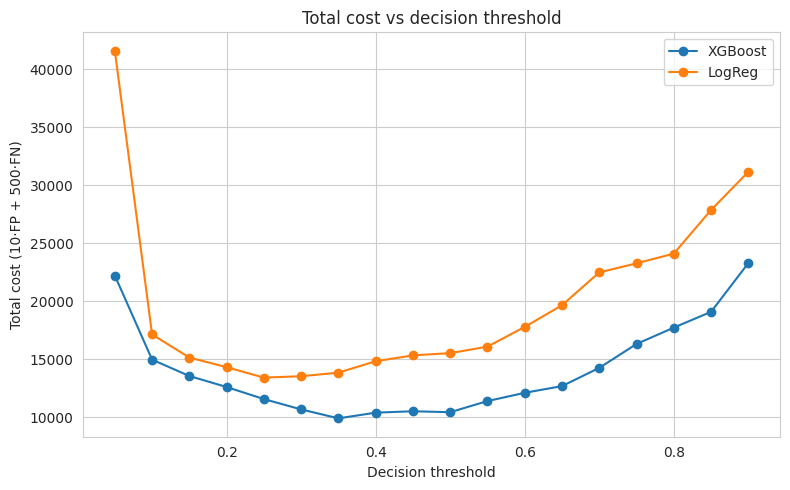

XGBoost: best threshold = 0.35, cost = 9900, recall = 0.987, precision = 0.333
LogReg: best threshold = 0.25, cost = 13410, recall = 0.963, precision = 0.360


In [ ]:
# plot total_cost vs threshold for the two top models
fig, ax = plt.subplots(figsize=(8, 5))
for name, sweep in threshold_sweep.items():
    ax.plot(sweep['threshold'], sweep['total_cost'], marker='o', label=name)
ax.set_xlabel('Decision threshold')
ax.set_ylabel('Total cost (10·FP + 500·FN)')
ax.set_title('Total cost vs decision threshold')
ax.legend()
plt.tight_layout()
plt.show()

# print the best threshold per top model
best_by_threshold = {}
for name, sweep in threshold_sweep.items():
    best_row = sweep.loc[sweep['total_cost'].idxmin()]
    best_by_threshold[name] = best_row
    print(f"{name}: best threshold = {best_row['threshold']}, cost = {int(best_row['total_cost'])}, "
          f"recall = {best_row['recall']:.3f}, precision = {best_row['precision']:.3f}")


## 12. Final model comparison


In [ ]:
final_df = results_df.copy()
final_df['tuned_threshold'] = np.nan
final_df['cost_at_tuned_threshold'] = np.nan
for name, row in best_by_threshold.items():
    final_df.loc[name, 'tuned_threshold'] = row['threshold']
    final_df.loc[name, 'cost_at_tuned_threshold'] = row['total_cost']

final_df


,best_cv_recall,accuracy,precision,recall,f1,roc_auc,TN,FP,FN,TP,total_cost,tuned_threshold,cost_at_tuned_threshold
XGBoost,0.947004,0.962375,0.381648,0.976000,0.548726,0.993618,15032.0,593.0,9.0,366.0,10430.0,0.35,9900.0
LogReg,0.906008,0.976500,0.499289,0.936000,0.651206,0.989751,15273.0,352.0,24.0,351.0,15520.0,0.25,13410.0
DecisionTree,0.924988,0.958250,0.352170,0.930667,0.510981,0.951349,14983.0,642.0,26.0,349.0,19420.0,NaN,NaN
RandomForest,0.869013,0.978000,0.517774,0.893333,0.655577,0.990783,15313.0,312.0,40.0,335.0,23120.0,NaN,NaN
GradBoost,0.710986,0.992188,0.908497,0.741333,0.816446,0.994261,15597.0,28.0,97.0,278.0,48780.0,NaN,NaN
KNN,0.507999,0.988688,0.907563,0.576000,0.704731,0.943657,15603.0,22.0,159.0,216.0,79720.0,NaN,NaN


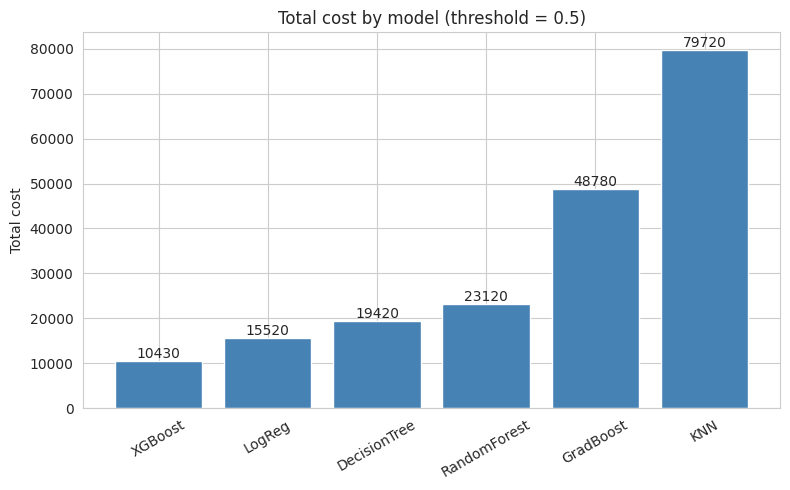

In [ ]:
# bar chart of total cost for each model
fig, ax = plt.subplots(figsize=(8, 5))
sorted_df = results_df.sort_values('total_cost')
ax.bar(sorted_df.index, sorted_df['total_cost'], color='steelblue')
ax.set_ylabel('Total cost')
ax.set_title('Total cost by model (threshold = 0.5)')
plt.xticks(rotation=30)
for i, v in enumerate(sorted_df['total_cost']):
    ax.text(i, v, f'{int(v)}', ha='center', va='bottom')
plt.tight_layout()
plt.show()


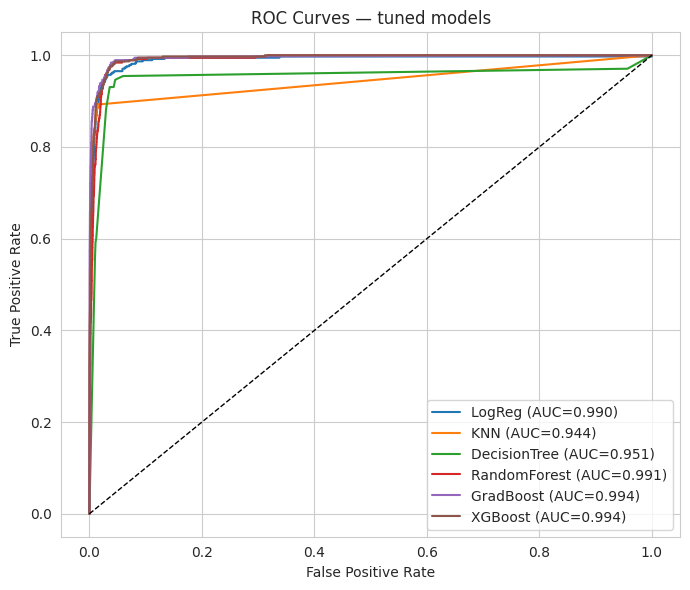

In [ ]:
# ROC curves for all tuned models
fig, ax = plt.subplots(figsize=(7, 6))
for name, gs in tuned.items():
    best = gs.best_estimator_
    if not hasattr(best, 'predict_proba'):
        continue
    proba = best.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves - tuned models')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()


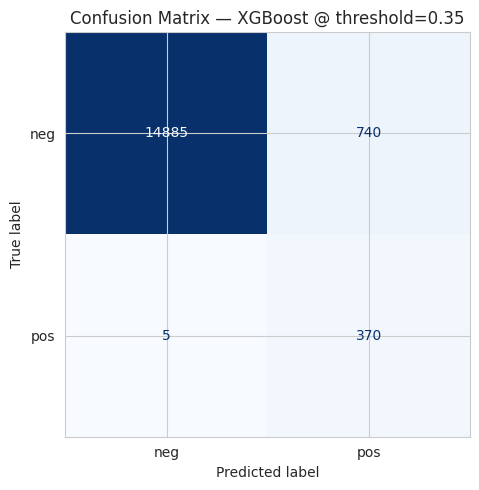

Best model: XGBoost at threshold 0.35
              precision    recall  f1-score   support

         neg       1.00      0.95      0.98     15625
         pos       0.33      0.99      0.50       375

    accuracy                           0.95     16000
   macro avg       0.67      0.97      0.74     16000
weighted avg       0.98      0.95      0.96     16000

Total cost: 9900


In [ ]:
# confusion matrix for the best model
best_model_name = min(best_by_threshold.keys(),
                      key=lambda n: best_by_threshold[n]['total_cost'])
best_pipe = tuned[best_model_name].best_estimator_
best_thresh = float(best_by_threshold[best_model_name]['threshold'])

y_proba = best_pipe.predict_proba(X_test)[:, 1]
y_pred_best = (y_proba >= best_thresh).astype(int)

cm = confusion_matrix(y_test, y_pred_best, labels=[0, 1])
disp = ConfusionMatrixDisplay(cm, display_labels=['neg', 'pos'])
fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'Confusion Matrix — {best_model_name} @ threshold={best_thresh}')
plt.tight_layout()
plt.show()

print(f'Best model: {best_model_name} at threshold {best_thresh}')
print(classification_report(y_test, y_pred_best, target_names=['neg', 'pos']))
print(f'Total cost: {total_cost(y_test, y_pred_best)}')


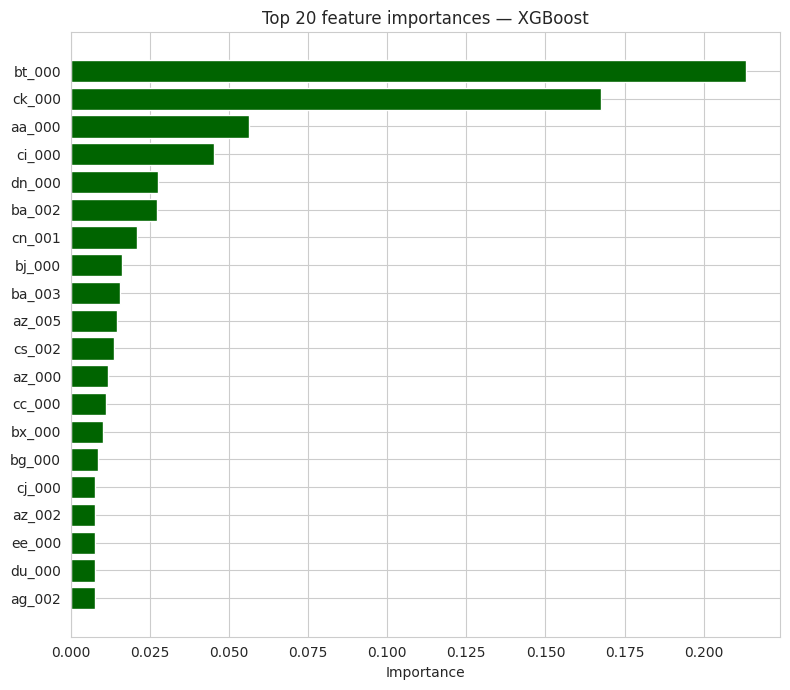

In [ ]:
# feature importance
fi_model_name = 'XGBoost' if 'XGBoost' in tuned else 'RandomForest'
fi_pipe = tuned[fi_model_name].best_estimator_
fi_clf = fi_pipe.named_steps['clf']

if hasattr(fi_clf, 'feature_importances_'):
    importances = pd.Series(fi_clf.feature_importances_, index=feature_cols)
    top20 = importances.sort_values(ascending=False).head(20)

    fig, ax = plt.subplots(figsize=(8, 7))
    ax.barh(top20.index[::-1], top20.values[::-1], color='darkgreen')
    ax.set_title(f'Top 20 feature importances — {fi_model_name}')
    ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.show()
else:
    print(f'{fi_model_name} has no feature_importances_ attribute.')
